# PyTorch Workflow
let's explore an example PyTorch end-to-end workflow
Resources:
* 

In [318]:
What_were_covering = {1: "data (prepare and load)",
                      2: "build model",
                      3: "fitting the model to data (trainign)",
                      4: "making predictions and evaluting a model (inference)",
                      5: "saving and loading a model",
                      6: "putting it all together"}

What_were_covering


{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (trainign)',
 4: 'making predictions and evaluting a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [319]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for nerual network
import matplotlib.pyplot as plt
import numpy as np

# Check PyTorch version
torch.__version__

'2.11.0+cu130'

## Data (preparing and loading)

Data can be almost anything... in machine learning

* Excel spreadsheet
* Image of any kind
* Videos
* Audio
* DNA 
* Text 

Machine Learning is a game of two parts: 
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation

To showcase this, let's create some *known* data using the linear regression.

In [320]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
x = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * x + bias

x[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [321]:
len(x), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

let's create a training and test est with our data

In [322]:
# Create a train/test split
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize"

In [323]:
def plot_prediction(train_data=x_train,
                    train_labels=y_train,
                    test_data=x_test,
                    test_labels=y_test,
                    predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    
    plt.figure(figsize=(10, 7))
    
    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
    
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="r", s=4, label="Testing Data")
    
    # Are there predictions?
    if predictions is not None:
        # Plot the predictions if they exists
        plt.scatter(test_data, predictions, c="r", label="Predictions")
        
    # Show legend
    plt.legend(prop={"size":14});

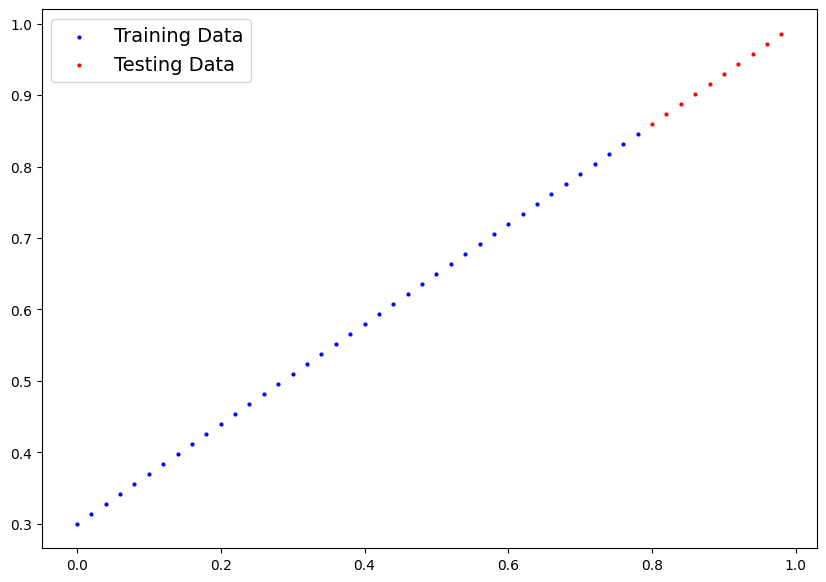

In [324]:
plot_prediction();

## 2. Build Model

Simple first model

python OOP: https://realpython.com/python3-object-oriented-programming/

what our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random value to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through Two main algorithms:
1. Gradient descent - https://youtu.be/IHZwWFHWa-w
2. Backpropagation - https://youtu.be/Ilg3gGewQ5U

In [325]:
# Create a linear regression model class
# almost everything in PyTorch inherits from nn.Module
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(1, # <- start with random weight and try to adjust it to the ideal weight
                                               requires_grad=True, # <- can this parameter be updated via graident descent?
                                               dtype=torch.float32)) # <- PyTorch loves the datatype torch.float32
        
        self.bias = nn.Parameter(torch.rand(1, # <- start with random bias and try to adjust it to the ideal bias
                                            requires_grad=True, # <- can this parameter updated via gradient descent?
                                            dtype=torch.float32)) # <- PyTroch loves the datatype toch.float32
        
    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return self.weights* x + self.bias # linear regression formula y = a + bx
        

### PyTorch model building essentials

* `torch.nn` - contains all of buildings for computational graphs(a nerual network can be considered computational graphy)
* `torch.nn.Parameter` - what paraemters should our model try and learn, often a PyTorch layer from `torch.nn` will set these for us
* `torch.nn.Module`  - the base class for all neural network modules, if you subclass it, you should overwrite forward()
* `torch.optim` - this where the optimizers in PyTorch live, they help with gradient descent
* `def forward()` - all nn.Module subclass require you to overwrite forward(), this method defines what happens in the forward computation

see more of these essential via PyTorch cheatsheet = https://www.learnpytorch.io/pytorch_cheatsheet/


### Checking the contents of our PyTorch model

Now we've created a model, lets see what's inside..
So we can check our model parameters or what's inside our model using `.parameters()`

In [326]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [327]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

### Making prediction using ` torch.inference_mode()

To check our model's predective power, let's see how well it predicts `y_test` based on `x_test`.

When we pass the data through our model, it's going to run it through `forward()` method

In [328]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(x_test)
    
# You can do same with torch.no_grad(), however torch.inference_mode() is preferred
# with torch.no_grad():
#     y_preds = model_0(x_test)

y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [329]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

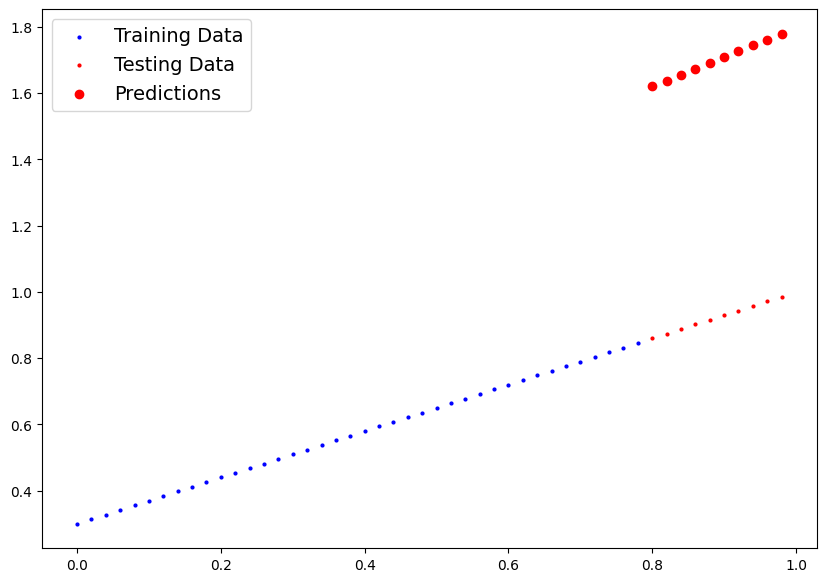

In [330]:
plot_prediction(predictions=y_preds)

## Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some known parameters.

Or in other words from a poor representation of the data to a better representation  of the data.

One way to measure how poor or how wrong your model predictions are is to use loos functions.

* **NOTE:** Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

* **Loss Function:** : A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of model and adjust the model's parameters (e.g. weight & bias in our case) to improve the loss function.
    * Inside the optimizer you'll often have to set two parameter:
        * `params` - the model parameter you'd like to optimize, for example: `params=model_0.parameters()`
        * `lr` (learning rate) - the learning rate is a hyperparameter that defines how big/small optimizer changes the parameter with each step (a small `lr` results in small changes, a large `lr` results in large changes)

And specifically for PyTorch, we need:
* A training loop
* A testing loop 

In [331]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [332]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [333]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # lr -> learning rate = possibly the most important hyperparameter you can set

Q: which loss function and optimizer should i use?

A: This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example, for a regression prblem (like ours), a loss function of `nn.L1Loss()` and an optimizer like `torch.optim.SGD()` will suffice.

But for classification problems like classifying whether a photo is of a dog or a cat, you'll likely want to use a loss fucntion of `nn.BCELoss()` (binary cross entropy).

### Building a training loop ( and testing loop) in PyTorch

A couple of things we need in training loop:
0.  Loop through the data
1. Forward pass - (this involves data moving through our model's `forward()` function) - also called forward propagation
2. Calculate the loss - (compare forward pass predictions to ground truth labels)
3. Optimizer Zero gradients
4. Loss backward - movies backward through the network to calculate the graidents of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's paramters to try and improve loss (**graident descent**)

In [334]:
# Set the number of epochs (how many times the model will pass over the training data)
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []


### Training

# 0. Loop through the data
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train mode in PyTorch sets all parameters that require graidents to require graidents

    # 1. Forward pass
    y_pred = model_0(x_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    print(f"Loss:{loss}")


    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimizer changes will acculumate through the loop so... we have to zero them above in step 3 for next iteration of the loop

    ### Testing
    model_0.eval() # (turns off different settings in the model not needed for evaluation/testing(dropout/batch norm layer) )
    with torch.inference_mode(): # turns off graident tracking
    # with torch.no_grad(): # you may also see torch.no_grad() in older PyTorch code
        # 1. Do the forward pass
        test_pred = model_0(x_test)
        
        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)
        
    # Print our what's happening
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
        
        # Print out model state_dict()
        print(model_0.state_dict())

Loss:0.6860889196395874
Epoch: 0 | Loss: 0.6860889196395874 | Test Loss: 0.7637526988983154
OrderedDict([('weights', tensor([0.8784])), ('bias', tensor([0.9050]))])
Loss:0.6745679974555969
Loss:0.6630470156669617
Loss:0.6515260338783264
Loss:0.6400049924850464
Loss:0.6284840703010559
Loss:0.6169630289077759
Loss:0.6054420471191406
Loss:0.5939210653305054
Loss:0.5824000239372253
Loss:0.5708791017532349
Epoch: 10 | Loss: 0.5708791017532349 | Test Loss: 0.6290428042411804
OrderedDict([('weights', tensor([0.8394])), ('bias', tensor([0.8050]))])
Loss:0.5593580603599548
Loss:0.5478371381759644
Loss:0.5363161563873291
Loss:0.5247951149940491
Loss:0.5132741332054138
Loss:0.5017532110214233
Loss:0.4902321696281433
Loss:0.47871121764183044
Loss:0.4671902060508728
Loss:0.45566922426223755
Epoch: 20 | Loss: 0.45566922426223755 | Test Loss: 0.4943329691886902
OrderedDict([('weights', tensor([0.8004])), ('bias', tensor([0.7050]))])
Loss:0.4441482126712799
Loss:0.43262726068496704
Loss:0.421106249094

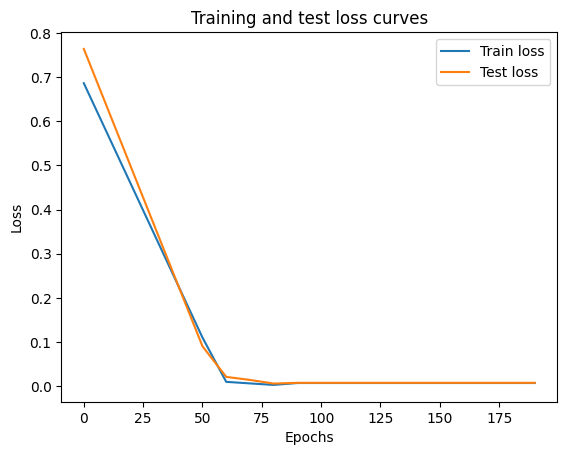

In [335]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label='Train loss')
plt.plot(epoch_count, test_loss_values, label='Test loss')
plt.title('Training and test loss curves')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend();

In [336]:
with torch.inference_mode():
    y_preds_new = model_0(x_test)

In [337]:

model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [338]:
weight, bias

(0.7, 0.3)

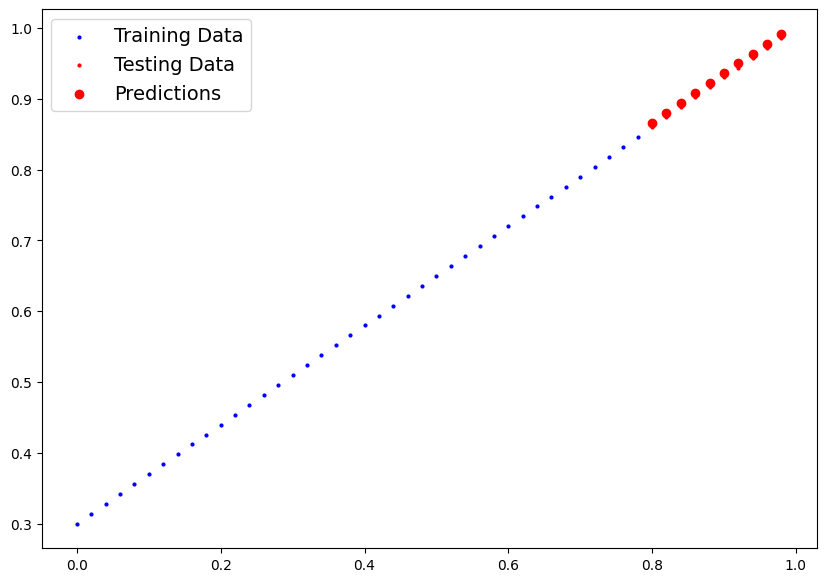

In [339]:
plot_prediction(predictions=y_preds_new)

## Saving a model in PyTorch

There are three main methods you should know about for saving and loading models in PyTorch.

1. `torch.save()` - allows you to save PyTorch object in python's pickle format
2. `torch.load()` - allows you to load a saved pytorch object
3. `torch.nn.Module.load_state_dict()` - allows you to load a model's saved state dictionary

PyTorch save and load code tutorial: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

In [ ]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create a model directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), 
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth
